# 12 — Hub vs geometry

Correlate **degree** with `Inf.Hyp.Rad`, `Inf.Kappa`, and **‖stereo(w)‖** in R³.


### Degree vs model coordinates and ball radius

**Method:** Stereographic `S³→ℝ³` gives `(X,Y,Z)`; Euclidean norm `r_ball` is the distance from the origin in **this** chart. Pearson correlations are printed among `degree`, `Inf.Hyp.Rad`, `Inf.Kappa`, and `r_ball`; a hexbin plot shows degree vs hyperbolic radius density.

**How to read the output:** Strong **degree vs Inf.Hyp.Rad** correlation matches common “popularity” interpretations in hyperbolic-like models, but correlation ≠ causation. `r_ball` mixes projection with native radius—interpret cautiously. The next cell adds **betweenness centrality** on the **full induced subgraph** of vertices present in both `merged` and the PPI (no random vertex cap). `degree` remains **full-graph** degree from `merged`; betweenness is a **second hub measure** (shortest-path load) on that same induced subgraph—use it as a bridge-flow proxy; it need not track degree.


               degree  Inf.Hyp.Rad  Inf.Kappa    r_ball
degree       1.000000    -0.704976   0.881685 -0.041420
Inf.Hyp.Rad -0.704976     1.000000  -0.500375  0.006677
Inf.Kappa    0.881685    -0.500375   1.000000 -0.032813
r_ball      -0.041420     0.006677  -0.032813  1.000000


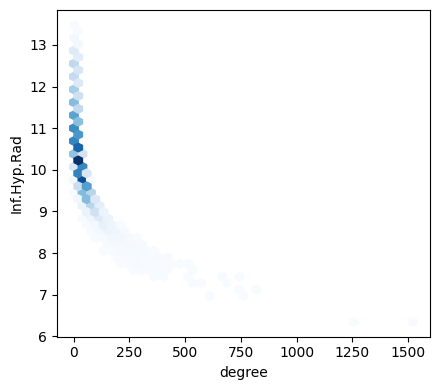

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import dmercator3d_io as dm
from ball_projection import stereographic_s3_to_r3

m = dm.load_merged_parquet(Path("cache/merged.parquet"))
U = dm.normalize_direction_nd(m)
x1, x2, x3, x4 = U[:, 0], U[:, 1], U[:, 2], U[:, 3]
X, Y, Z = stereographic_s3_to_r3(x1, x2, x3, x4)
r = np.sqrt(X * X + Y * Y + Z * Z)
df = m.assign(r_ball=r)
cols = ["degree", "Inf.Hyp.Rad", "Inf.Kappa", "r_ball"]
print(df[cols].corr())

fig, ax = plt.subplots(figsize=(4.5, 4))
ax.hexbin(df["degree"], df["Inf.Hyp.Rad"], gridsize=40, cmap="Blues", mincnt=1)
ax.set_xlabel("degree")
ax.set_ylabel("Inf.Hyp.Rad")
plt.tight_layout()
plt.show()


### Betweenness on the full induced subgraph

**Induced subgraph:** we take **every** vertex that appears in both `merged` and `edges_GC.edge` (same overlap as notebook `11`), then restrict `G` to those nodes—**no random subsampling** of vertices.

**Computation:** NetworkX `betweenness_centrality(..., k=None)` is **exact** on that subgraph (all-pairs shortest paths via pivots). On very large or dense graphs this can be slow; if needed, switch to approximate `k` in code.

**How to read it:** Correlations are Pearson on rows with a non-NaN betweenness (vertices missing from `G` stay NaN). **Degree** is global from `merged`; **betweenness** is load **inside** the induced subgraph, so it can diverge from degree (e.g. local bridges).

In [ ]:
import os

import networkx as nx

RUN_SUBDIR = os.environ.get("DMERCATOR_RUN", "d3")
paths = dm.paths_for_run(RUN_SUBDIR)
G = dm.load_edges_graph(paths["edge"])

vert_set = set(df["Vertex"].astype(str))
nodes = [n for n in G.nodes() if str(n) in vert_set]
subG = G.subgraph(nodes).copy()
n_sub = subG.number_of_nodes()
m_sub = subG.number_of_edges()
if n_sub < 2:
    raise RuntimeError("induced subgraph has < 2 vertices — check edge/coord overlap")

betw = nx.betweenness_centrality(subG, k=None, normalized=True, seed=7)
betw_map = {str(v): float(betw[v]) for v in betw}

df = df.assign(betweenness_subgraph=df["Vertex"].astype(str).map(betw_map))
have = df["betweenness_subgraph"].notna()
bt_cols = ["betweenness_subgraph", "degree", "Inf.Hyp.Rad", "Inf.Kappa", "r_ball"]

print(
    f"Betweenness (exact, k=None): RUN_SUBDIR={RUN_SUBDIR!r}  |V_sub|={n_sub}  |E_sub|={m_sub}  "
    f"rows with score: {int(have.sum()):,} / {len(df):,}\n"
)
print(df.loc[have, bt_cols].corr())
